# Imports

In [1]:
import pandas as pd
import os
import geopandas as gpd
from pathlib import Path
from shapely.geometry import Point

# Merge Roads and Bridges Data

In [2]:
# BASE_DIR = Path(__file__).parent
# DATA_DIR = BASE_DIR / "data"
data_dir = "../data/"

raw_df      = pd.read_csv("../data/_roads3.csv")
bridge_info = pd.read_excel("../data/BMMS_overview.xlsx")
# print(f"  {len(raw_df):,} LRP rows  |  {raw_df['road'].nunique()} roads  |  "
#       f"{len(bridge_info):,} bridge records")

df = raw_df.copy()
df["id"] = range(len(df))

df["length"] = (
    df.groupby("road")["chainage"]
    .diff().abs().fillna(0) * 1000
)

# normalise strings
df["road"] = df["road"].astype(str).str.strip()
df["lrp"]  = df["lrp"].astype(str).str.strip()
df["name"] = df["name"].astype(str).fillna("").str.strip()

# type_simple: Bridge or raw type prefix
df["type_simple"] = df["type"].apply(
    lambda x: "Bridge"
    if isinstance(x, str) and "bridge" in x.lower()
    else str(x).split(" / ")[0].split("%")[0]
)
# merge and aggregate bridge
bridge_info.columns    = bridge_info.columns.str.strip()
bridge_info["LRPName"] = bridge_info["LRPName"].astype(str).str.strip()

def aggregate_bridge_group(group):
    names_str  = " ".join(group["name"].dropna().astype(str).tolist()).upper()
    is_lr_pair = (("(L)" in names_str or " L " in names_str) and
                  ("(R)" in names_str or " R " in names_str))
    return pd.Series({
        "length":    group["length"].median() if is_lr_pair else group["length"].mean(),
        "condition": group["condition"].max(),   # worst condition (D > A)
        "name":      group["name"].iloc[0],
    })

bridge_info_clean = (
    bridge_info.groupby("LRPName", dropna=False)
    .apply(aggregate_bridge_group)
    .reset_index()
    .rename(columns={"length": "length_bmms"})
)

df = df.merge(
    bridge_info_clean,
    left_on="lrp", right_on="LRPName",
    how="left", suffixes=("", "_bmms")
)

mask_bridge       = df["type_simple"] == "Bridge"
mask_has_bmms_len = df["length_bmms"].notna()

df.loc[mask_bridge & mask_has_bmms_len, "length"] = (
    df.loc[mask_bridge & mask_has_bmms_len, "length_bmms"]
)
if "condition_bmms" in df.columns:
    df.loc[mask_bridge, "condition"] = df.loc[mask_bridge, "condition_bmms"]
df.loc[mask_bridge, "condition"] = df.loc[mask_bridge, "condition"].fillna("Unknown")

df = df[df["road"].str.match(r"^[NR]", na=False)].copy()
df['model_type'] = df['type_simple'].apply(
    lambda x: 'bridge' if x == 'Bridge' else 'link'
)

df_roads_bridges = df.sort_values(["road", "chainage"]).reset_index(drop=True)

geometry  = [Point(xy) for xy in zip(df_roads_bridges['lon'], df_roads_bridges['lat'])]
gdf_roads = gpd.GeoDataFrame(df_roads_bridges, geometry=geometry, crs="EPSG:4326")

print(f"  After preprocessing: {len(gdf_roads):,} rows  |  bridges: {mask_bridge.sum()}")


output_path = "../data/roads_after_dataanalysis.csv"
gdf_roads.to_csv(output_path, index=False)

  After preprocessing: 19,512 rows  |  bridges: 9101


---

# Criticality

## Load Relevant HTM data for N and R roads

In [3]:
col_names = [
    "link_no", "name",
    "start_lrp", "start_offset", "start_chainage",
    "end_lrp", "end_offset", "end_chainage",
    "length_km",
    "heavy_truck", "medium_truck", "small_truck",
    "large_bus", "medium_bus", "micro_bus",
    "utility", "car", "auto_rickshaw", "motorcycle", "bicycle",
    "cycle_rickshaw", "cart",
    "motorized_total", "non_motorized_total",
    "total_aadt", "aadt"
]

data_dir = "../data/traffic/"
all_dfs = []

for filename in os.listdir(data_dir):
    if filename.endswith(".traffic.htm"):
        filepath = os.path.join(data_dir, filename)
        try:
            tables = pd.read_html(filepath, encoding="iso-8859-1", match="List of links")
            df = tables[0].copy()
            df.columns = col_names
            df = df[df["link_no"].str.strip().str.match(r"^[A-Z]+\d+-\d+", na=False)]
            df = df.reset_index(drop=True)
            df["road"] = filename.replace(".traffic.htm", "")
            all_dfs.append(df)
        except Exception as e:
            print(f"Skipped {filename}: {e}")

criticality_df = pd.concat(all_dfs, ignore_index=True)

cols_needed = ['road', 'link_no', 'name',
               'start_lrp', 'start_chainage',
               'end_lrp',   'end_chainage',
               'heavy_truck', 'medium_truck', 'small_truck']
criticality_df = criticality_df[cols_needed].copy()

for col in ['heavy_truck', 'medium_truck', 'small_truck']:
    criticality_df[col] = pd.to_numeric(criticality_df[col], errors='coerce').fillna(0)

criticality_df['start_chainage'] = pd.to_numeric(criticality_df['start_chainage'], errors='coerce')
criticality_df['end_chainage']   = pd.to_numeric(criticality_df['end_chainage'],   errors='coerce')

criticality_df['criticality_score'] = (
    criticality_df['heavy_truck']  * 15 +
    criticality_df['medium_truck'] * 7  +
    criticality_df['small_truck']  * 3
)


In [4]:
criticality_df.head(5)

,road,link_no,name,start_lrp,start_chainage,end_lrp,end_chainage,heavy_truck,medium_truck,small_truck,criticality_score
0,R311,R311-1,BARI More (int with R310) - Ordinance Factory ...,LRPS,0.000,LRP005,4.561,0.0,226.0,343.0,2611.0
1,R203,R203-1,Bhulta(int.with N2)-Araihazar(int.with R114),LRPS,0.000,LRP005,9.100,0.0,204.0,155.0,1893.0
2,R203,R203-2,Araihazar(int.with R114)-Biskandi Ferry ghat,LRP005,9.100,LRP014,18.140,0.0,204.0,155.0,1893.0
3,R203,R203-3,Biskandi Ferry ghat- Bancharampur(int.with Z1043),LRP014,18.140,LRP028,28.552,0.0,204.0,155.0,1893.0
4,R203,R203-4,Bancharampur(int.with Z1043)-Fathepur more(int...,LRP028,28.552,LRP028,32.426,0.0,22.0,20.0,214.0


## Map Roads and Bridges to Road Link number

In [5]:
# Merge op road, dan filteren op chainage range
merged = gdf_roads[['road', 'lrp', 'chainage']].merge(
    criticality_df[['road', 'link_no', 'start_chainage', 'end_chainage', 'criticality_score']],
    on='road', how='left'
)

merged = merged[
    (merged['chainage'] >= merged['start_chainage']) &
    (merged['chainage'] <= merged['end_chainage'])
]

# Één segment per LRP (drop duplicates voor het geval van grenspunten)
segment_per_lrp = (
    merged[['road', 'lrp', 'link_no', 'criticality_score']]
    .drop_duplicates(subset=['road', 'lrp'])
)

# Terugmergen op gdf_roads
gdf_roads = gdf_roads.merge(segment_per_lrp, on=['road', 'lrp'], how='left')

In [6]:
gdf_roads.tail()

,road,chainage,lrp,lat,lon,gap,type,name,id,length,type_simple,LRPName,length_bmms,condition,name_bmms,model_type,geometry,link_no,criticality_score
19507,R890,107.665,LRP106b,22.074888,90.618860,NaN,Culvert,Box Culvert,19507,558.0,Culvert,LRP106b,10.423333,A,KHATABARI CULVERT,link,POINT (90.61886 22.07489),R890-6,2093.0
19508,R890,107.895,LRP107,22.076666,90.619444,NaN,KmPost,Km post missing,19508,230.0,KmPost,NaN,NaN,NaN,NaN,link,POINT (90.61944 22.07667),R890-6,2093.0
19509,R890,108.105,LRP107a,22.078444,90.620166,NaN,Culvert,Box Culvert,19509,210.0,Culvert,LRP107a,20.704444,D,MIABAZAR BOX CULVERT,link,POINT (90.62017 22.07844),R890-6,2093.0
19510,R890,108.455,LRP107b,22.079694,90.617388,NaN,Culvert,Box Culvert,19510,350.0,Culvert,LRP107b,4.475000,B,W LOUSHINIPOR BOX CULVERT,link,POINT (90.61739 22.07969),R890-6,2093.0
19511,R890,108.785,LRPE,22.080888,90.614389,NaN,Others,"End of road at Baburhat, Launch Ghate,Bhola.",19511,330.0,Others,NaN,NaN,NaN,NaN,link,POINT (90.61439 22.08089),R890-6,2093.0


---

# Vulnerability

## Load Vulnerability Data

In [7]:
# Load Flood Data
gdf_flood = gpd.read_file('../data/flood shapefile/bgd_nhr_floods_sparsso.shp')
# Normalise intensity (Severity mapping: 0→0, Severe→1.0, Moderate→0.6, Low→0.3)
flood_intensity = {0:0.0, 1:1.0, 2:0.6, 3:0.3, 4:1.0, 5:0.6, 6:0.3, 7:1.0, 8:0.6}
gdf_flood['flood_hazard_val'] = gdf_flood['FLOODCAT'].astype(int).map(flood_intensity)

# Load Earthquake Data
gdf_eq = gpd.read_file('../data/earthquake shapefile/bgd_nhr_earthquake_sparsso.shp')
eq_hazard_map = {'I': 1.0, 'II': 0.6, 'III': 0.3}
gdf_eq['eq_hazard_val'] = gdf_eq['ZONE'].map(eq_hazard_map).fillna(0.3)

print(f"Flood: {len(gdf_flood)} polygons; EQ: {len(gdf_eq)} polygons.")

Flood: 4440 polygons; EQ: 142 polygons.


## Spatial Join Vulnerability Data and Roads and Bridges

In [8]:
gdf_roads = gpd.sjoin(gdf_roads, gdf_flood[['geometry', 'flood_hazard_val', 'FLOODCAT']],
                      how='left', predicate='intersects')
if 'index_right' in gdf_roads.columns:
    gdf_roads = gdf_roads.drop(columns=['index_right'])

gdf_roads = gpd.sjoin(gdf_roads, gdf_eq[['geometry', 'eq_hazard_val', 'ZONE']],
                      how='left', predicate='intersects')

gdf_roads = gdf_roads.rename(columns={
    'flood_hazard_val': 'flood_hazard',
    'eq_hazard_val':    'eq_hazard',
    'ZONE':             'eq_zone',
    'FLOODCAT':         'flood_cat'
})

## Vulnerability Scoring

In [9]:
# 1. Map Internal Condition (A-D) to Scores 1-4
cond_to_score = {'A': 1, 'B': 2, 'C': 3, 'D': 4}
gdf_roads['int_cond_score'] = gdf_roads['condition'].map(cond_to_score).fillna(1)

# 2. Assign Multipliers for Environmental Hazards
# Earthquake Seismic Multiplier (Zone I=1.0, II=1.5, III=2.0)
seismic_map = {'I': 1.0, 'II': 1.5, 'III': 2.0}
gdf_roads['seismic_mult'] = gdf_roads['eq_zone'].map(seismic_map).fillna(1.0)

# Flood Hazard Multiplier
# Using  FLOODCAT normalisation logic from the script: max severity = 2.0x
# Mapping flood_hazard (0-1) to a multiplier (1.0 to 2.0)
gdf_roads['flood_mult'] = 1.0 + gdf_roads['flood_hazard']

# 3. Calculate Final Integrated Vulnerability Score
# We take the maximum multiplier between Flood and EQ to find the dominant threat
gdf_roads['max_hazard_mult'] = gdf_roads[['seismic_mult', 'flood_mult']].max(axis=1)

# Final Formula: Internal Condition Score * Maximum Environmental Hazard
gdf_roads['vulnerability_score'] = gdf_roads['int_cond_score'] * gdf_roads['max_hazard_mult']

---

# Visualising Vulnerability and Criticality

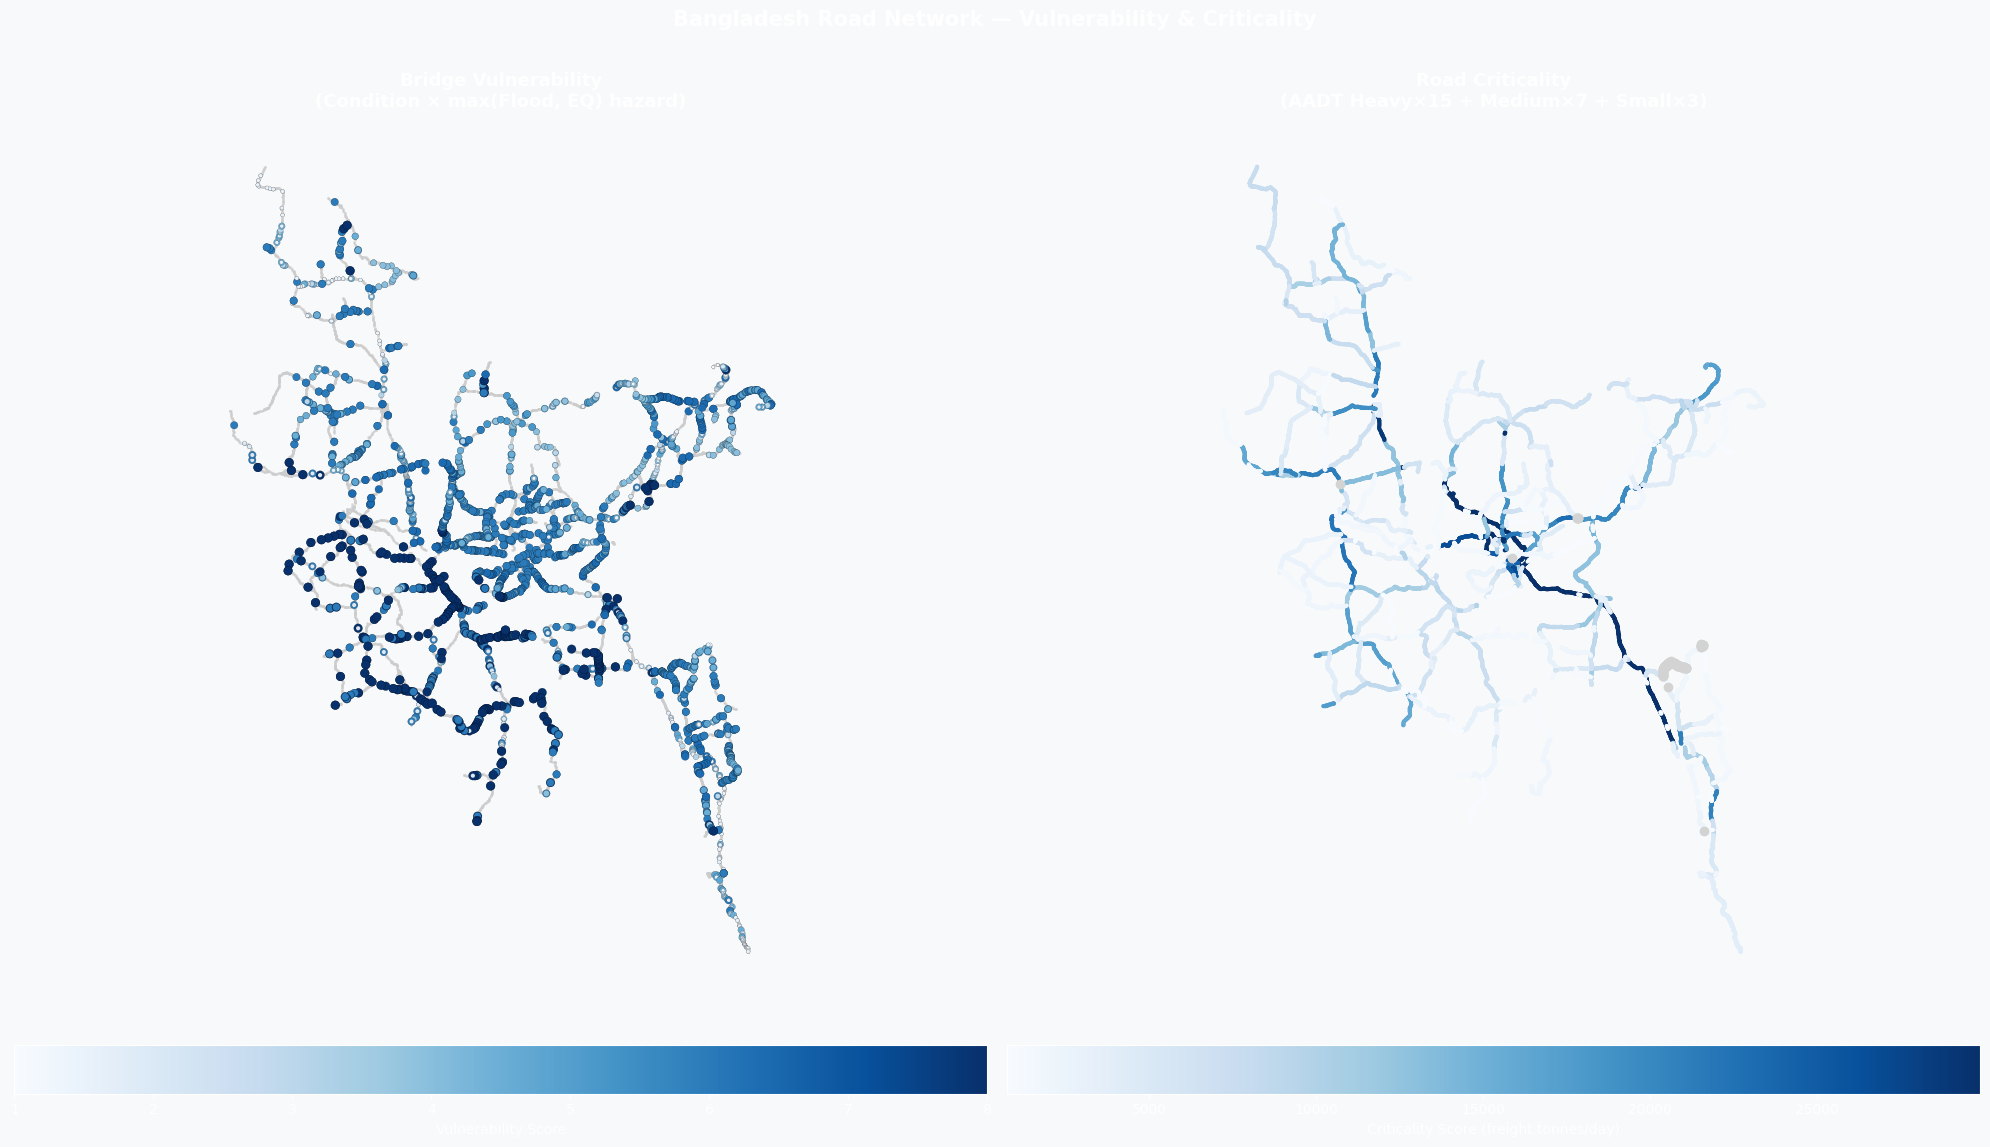

In [21]:
import matplotlib.pyplot as plt

links    = gdf_roads[gdf_roads['model_type'] == 'link']
bridges  = gdf_roads[gdf_roads['model_type'] == 'bridge']

fig, axes = plt.subplots(1, 2, figsize=(20, 12), facecolor='#f8f9fa')

# ── Links subplot helper ─────────────────────────────────────────────────────
LINK_KWARGS = dict(color='#cccccc', markersize=1, alpha=0.5, zorder=1)

# ── Left: Vulnerability ──────────────────────────────────────────────────────
ax = axes[0]
links.plot(ax=ax, **LINK_KWARGS)
bridges.plot(
    ax=ax,
    column='vulnerability_score',
    cmap='Blues',
    markersize=bridges['vulnerability_score'] * 5,
    edgecolor='black', linewidth=0.1,
    legend=True,
    legend_kwds={'label': "Vulnerability Score", 'orientation': "horizontal", 'pad': 0.05},
    zorder=2
)
ax.set_title("Bridge Vulnerability\n(Condition × max(Flood, EQ) hazard)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_axis_off()

# ── Right: Criticality ───────────────────────────────────────────────────────
ax = axes[1]
vmin = gdf_roads['criticality_score'].quantile(0.05)
vmax = gdf_roads['criticality_score'].quantile(0.95)

gdf_roads.plot(
    ax=ax,
    column='criticality_score',
    cmap='Blues',
    markersize=4,
    vmin=vmin, vmax=vmax,
    legend=True,
    legend_kwds={'label': "Criticality Score (freight tonnes/day)",
                 'orientation': "horizontal", 'pad': 0.05},
    missing_kwds={'color': 'lightgrey'},
    zorder=1
)
ax.set_title("Road Criticality\n(AADT Heavy×15 + Medium×7 + Small×3)",
             fontsize=13, fontweight='bold', pad=15)
ax.set_axis_off()

plt.suptitle("Bangladesh Road Network — Vulnerability & Criticality",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()